# **Análise Exploratória: Predominância dos Filmes de Língua Inglesa no Cinema Mundial**
  
**Responsável:** Ícaro Eduardo de Souza Lucena  
**Pergunta central:** O domínio dos filmes de língua inglesa está diminuindo?  
    
       
### **Motivação e Hipóteses:**  
No mundo todo, existe a ideia de que há uma predominância dos filmes de língua inglesa sobre os demais. Isso diz respeito principalmente à influência do cinema estadunidense no mundo, consequência da globalização. Além disso, também existe a ideia de que, por diversos fatores, o domínio dos filmes de língua inglesa no cinema mundial estaria diminuindo.  
  
  **Dito isto, pretende-se analisar essa hipótese segundo os seguintes fatores:**  
   1. A prevalência de filmes de língua inglesa de maneira geral;  
   1. A prevalência de filmes de língua inglesa entre os melhor avaliados;
  

In [25]:
import pandas
from matplotlib import pyplot as plt
import numpy


dados = pandas.read_csv("df_omdb.csv")
dados = dados[dados["startYear"] >= 1920] 

## A maioria dos filmes é de língua inglesa:  
  
  Para demonstrar que, de fato, os filmes de língua inglesa dominam o cinema mundial, é possível organizar as quantidades de filmes por idioma e exibir as frações em um gráfico de setores. Assim sendo, foram feitos os gráficos a seguir:
  

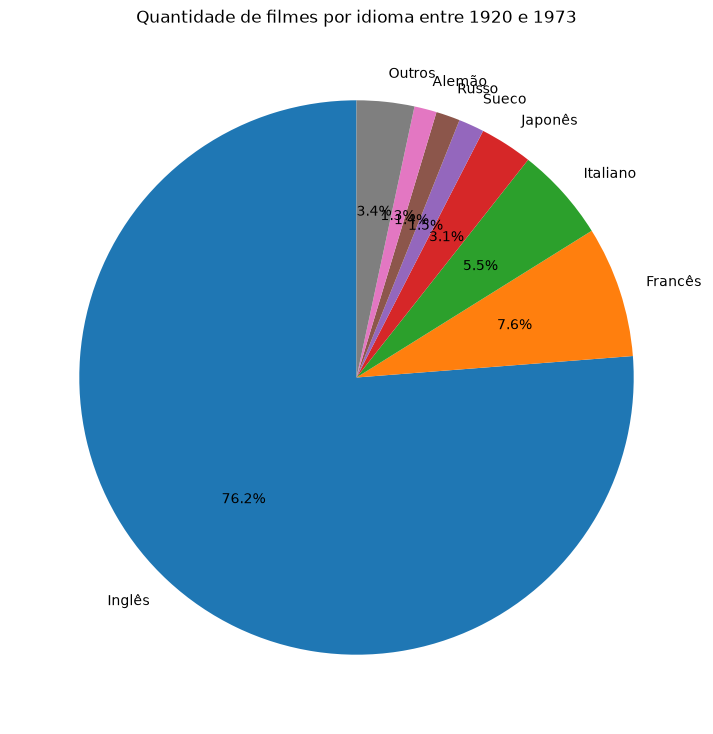

In [26]:
até73 = dados[dados["startYear"] < 1974]
até73 = até73["original_language"].value_counts()

top7 = até73.head(7)
top7 = top7.rename({
    "en": "Inglês",
    "fr": "Francês",
    "it": "Italiano",
    "ja": "Japonês",
    "de": "Alemão",
    "sv": "Sueco",
    "ru": "Russo"
})

outros = até73.iloc[7:].sum()
SérieIdioma = pandas.concat([top7, pandas.Series({"Outros": outros})])

plt.figure(figsize=(9,9))
plt.pie(
    SérieIdioma.values,
    labels = SérieIdioma.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Quantidade de filmes por idioma entre 1920 e 1973")
plt.show()

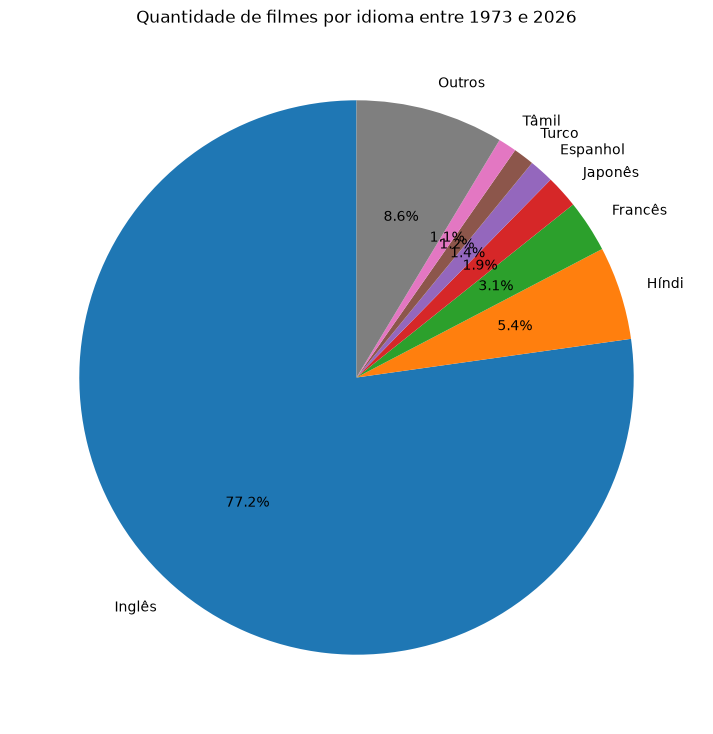

In [27]:
dps73 = dados[dados["startYear"] > 1972]
dps73 = dps73["original_language"].value_counts()

top7 = dps73.head(7)
top7 = top7.rename({
    "en": "Inglês",
    "hi": "Híndi",
    "fr": "Francês",
    "ja": "Japonês",
    "es": "Espanhol",
    "tr": "Turco",
    "ta": "Tâmil"
})

outros = dps73.iloc[7:].sum()
SérieIdioma = pandas.concat([top7, pandas.Series({"Outros": outros})])

plt.figure(figsize=(9,9))
plt.pie(
    SérieIdioma.values,
    labels=SérieIdioma.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Quantidade de filmes por idioma entre 1973 e 2026")
plt.show()

### Análise:  
  É perceptível que, em ambos os períodos, os filmes em língua inglesa compõem mais de três quartos da totalidade dos filmes lançados. No entanto, por esse gráfico, não se compreende que houve redução no domínio dos filmes de língua inglesa.

## Variação na porcentagem de filmes de língua inglesa:  
  
  Para demonstrar a variação no domínio dos filmes de língua inglesa ao longo do tempo, foram organizadas as porcentagens das quantidades de filmes em língua inglesa ao longo do tempo em um gráfico de barras.

In [28]:
comparaIngles = dados

comparaIngles["Inglês"] = comparaIngles["original_language"] == "en"


contagem = (
    comparaIngles.groupby(["startYear", "Inglês"])
    .size()
    .unstack(fill_value=0)
)

print(contagem)

contagem["total"] = contagem.sum(axis=1)
contagem["percentual_inglês"] = (
    contagem[True] / contagem["total"] * 100
)

contagem["percentual_outros"] = contagem[False]/contagem["total"]*100 
contagem["percentual_total"] = contagem["total"]/contagem["total"]*100



Inglês     False  True 
startYear              
1920           1      0
1921           1      1
1922           2      1
1923           0      2
1924           1      3
...          ...    ...
2022         129    250
2023         134    242
2024         109    213
2025         106    196
2026          18     59

[107 rows x 2 columns]


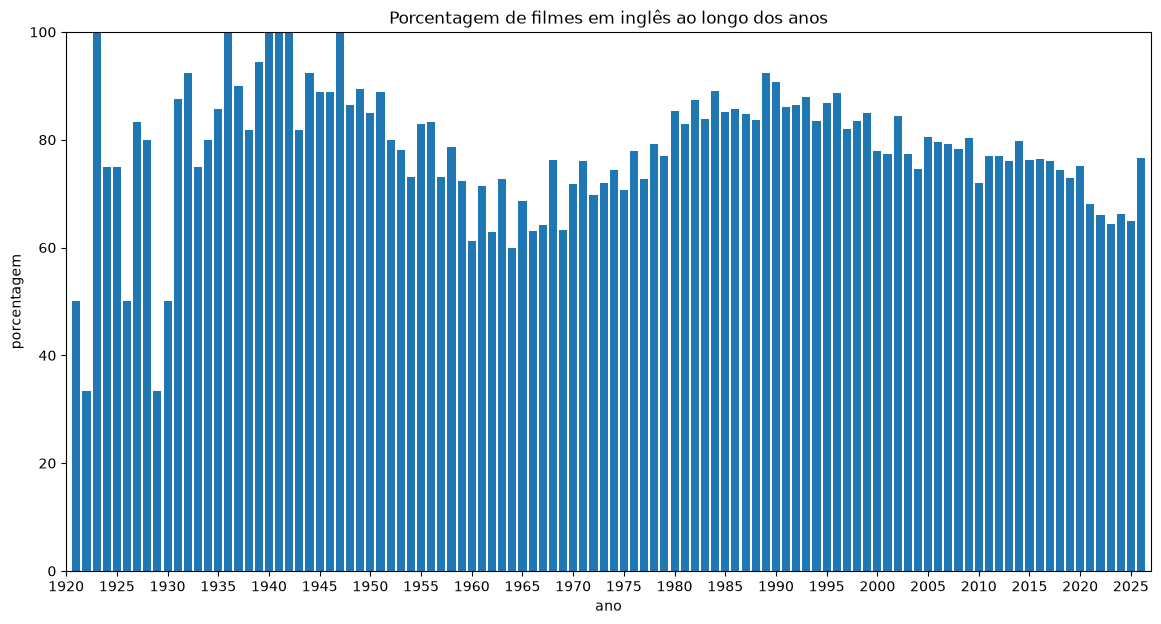

In [29]:
plt.figure(figsize=(14,7))

plt.bar(contagem["percentual_inglês"].index, contagem["percentual_inglês"].values)

plt.xlim(1920, 2027)
plt.ylim(0, 100)

plt.xticks(numpy.arange(1920, 2027, 5))

plt.xlabel("ano")
plt.ylabel("porcentagem")

plt.title("Porcentagem de filmes em inglês ao longo dos anos")

plt.show()

### Análise:  
  
  Por esse gráfico, é possível visualizar alguns anos de domínio absoluto da língua inglesa. Depois, uma queda durante certo período da Guerra Fria, após a Segunda Guerra Mundial. Com uma nova ascenção entre os anos 1970 e 1990, e uma pequena redução depois dos anos 90.


Para também demonstar como tal domínio se reflete na apreciação dos filmes, foram separadas e exibidas em um gráfico de barras as quantidades de filmes com nota 9 ou superior

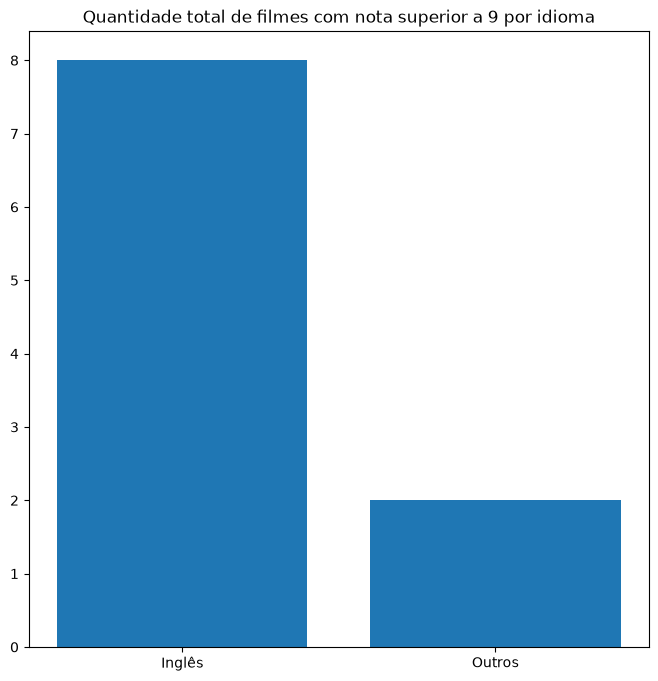

In [30]:
topNotas = dados[dados["averageRating"] >= 9]

topNotas = topNotas.groupby("original_language").size()

topIngles = topNotas.head(1)
topIngles = topIngles.rename({"en" : "Inglês"})

topOutros = topNotas.iloc[1:].sum()
SérieIdiomas = pandas.concat([topIngles, pandas.Series({"Outros": topOutros})])

plt.figure(figsize=(8,8))

plt.bar(SérieIdiomas.index, SérieIdiomas.values)
plt.title("Quantidade total de filmes com nota superior a 9 por idioma")
plt.show()

## Série histórica de filmes com nota maior ou igual a 7,5 (filmes em inglês x outros filmes)  
  
  A fim de explicitar a disparidade entre os filmes de língua inglesa e os filmes de outras línguas, tanto no geral quanto entre os mais bem avaliados, foram organizadas e exibidas em um gráfico de barras empilhadas as quantidades de filmes bem avaliados em duas categorias de idioma: "Inglês" e "Outros".

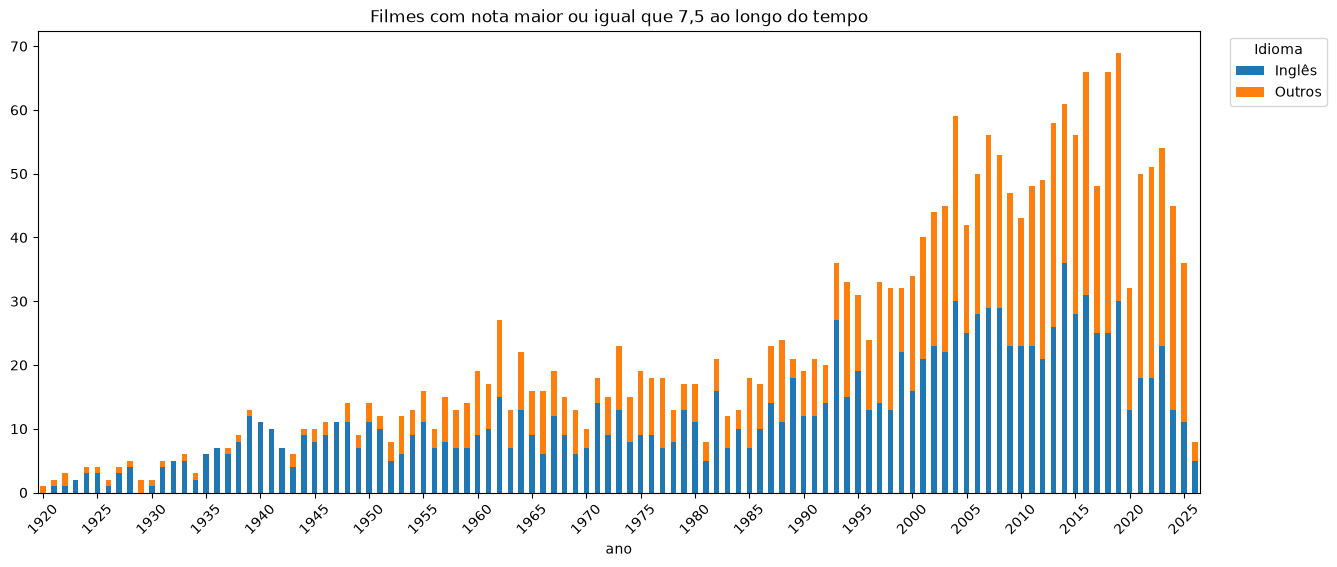

original_language  Inglês  Outros
startYear                        
1920                    0       1
1921                    1       1
1922                    1       2
1923                    2       0
1924                    3       1
...                   ...     ...
2022                   18      33
2023                   23      31
2024                   13      32
2025                   11      25
2026                    5       3

[107 rows x 2 columns]


In [31]:
dados["original_language"] = numpy.where(
    dados["original_language"] == "en", "Inglês",
    "Outros"
)

top = (
    dados[dados["averageRating"] >= 7.5]["original_language"]
    .value_counts()
    .index
)



agrupado = (
    dados[
        (dados["averageRating"] >= 7.5) &
        (dados["original_language"].isin(top))
    ]
    .groupby(["startYear", "original_language"])
    .size()
    .unstack(fill_value=0)
)


agrupado.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 6)
)

plt.xlabel("ano")

anos = agrupado.index

plt.xticks(
    ticks=range(0, len(anos), 5),
    labels=anos[::5],
    rotation=45
)


plt.title("Filmes com nota maior ou igual que 7,5 ao longo do tempo")
plt.legend(title="Idioma", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()
print(agrupado)

### Análise:  
  
  Com base no gráfico acima, depreende-se que, de fato, **houve uma grande diminuição na prevalência dos filmes anglófonos**, em comparação a filmes de outras línguas, entre os bem avaliados. Em muitos dos anos mais recentes, a língua inglesa não chega a ser maioria nos bem avaliados. 